<br>
<center>
    <h1 style="font-size: 2.5em;">Tutorial</h1>
    <h2 style="color: gray;">Corso di Social Media Data Analysis</h2>
    <hr style="width: 50%;">
    <p><b>Titolo:</b> Estrazione Dati e Analisi dei Trend Musicali tramite API di Spotify (1970-2022)</p>
    <p><b>Studente:</b> Kim Joy Randazzo 
    <p><i>Anno Accademico 2025/2026</i></p>
</center>
<br>

### 
Questo progetto illustra il processo di estrazione e analisi dei metadati musicali utilizzando le Web API di Spotify e dataset storici integrativi. L'obiettivo principale è esplorare l'evoluzione delle *Audio Features* (come felicità, energia e ballabilità) negli ultimi 50 anni. Attraverso l'uso di librerie Python (Pandas, NumPy, Matplotlib), verranno strutturati i dati, calcolate le matrici di correlazione e visualizzati i trend storici, al fine di dimostrare come la musica rifletta quantitativamente i cambiamenti culturali e l'impatto dell'era dello streaming.

# Spotify's Web API
---
## Introduzione
L'API di Spotify (Application Programming Interface) è un insieme di strumenti e protocolli che consente agli sviluppatori di integrare le funzionalità di Spotify nelle proprie applicazioni. Permette di accedere a metadati su brani, artisti, album e gestire i dati dell'utente, come playlist e brani preferiti.

Per avere accesso all'API di Spotify è necessario creare un'applicazione nella Dashboard, https://developer.spotify.com, li sarà possibile creare una nuova applicazione web.

![Errore caricamento immagine](Immagini/Home.png)

![Errore caricamento immagine...](Immagini/create.png)

## Setup
---
Dopo aver selezionato Create App basterà inserire il nome, una breve descrizione e selezionare Web API.
Inseriremo inoltre 'http://127.0.0.1:8888/callback' nella sezione Redirect URIs, necessario per la prossima sezione del tutorial

> Nota: dall' 11 Febbraio 2026 è necessario un abbonamento a Spotify Premium per poter utilizzare la Web Api!

![Errore caricamento immagine...](Immagini/info.png)

In [ ]:
import os
from dotenv import load_dotenv
import requests as rq
import base64

#Memorizziamo i valori per un più facile accesso
load_dotenv()

client_id = os.getenv('SPOTIFY_API_ID')
client_secret = os.getenv('SPOTIFY_API_SECRET')
redirect_uri = 'http://127.0.0.1:8888/callback'

# Definiamo una funzione per ottenere il token
def get_access_token(client_id, client_secret):
    auth_string = f"{client_id}:{client_secret}"
    auth_bytes = auth_string.encode("utf-8")
    auth_base64 = str(base64.b64encode(auth_bytes), "utf-8")

    # Definiamo l'endpoint a cui verrà effettuata la richiesta
    url = "https://accounts.spotify.com/api/token"
    headers = {
        "Authorization": f"Basic {auth_base64}",
        "Content-Type": "application/x-www-form-urlencoded"
    }
    data = {"grant_type": "client_credentials"}

    # Effettuiamo una richiesta POST per ottenere il token

    response = rq.post(url, headers=headers, data=data)
    
    if response.status_code == 200:
        token_data = response.json()
        return token_data['access_token']
    else:
        print(f"Errore: {response.status_code}")
        print(response.json())
        return None
    
access_token = get_access_token(client_id, client_secret)

print(access_token)

Avendo ora un Token possiamo iniziare a fare richieste.  

Le risposte saranno in formato JSON, utilizzeremo la libreria per facilitarne la visualizzazione e per capirne la struttura. 

Iniziamo richiedendo le informazioni di un'artista...

In [2]:
import json

def get_artist(artist_id, token):
    artist_url = f'https://api.spotify.com/v1/artists/{artist_id}'

    headers = {
        'Authorization': f'Bearer {token}'
    }

    response = rq.get(artist_url, headers=headers)

    if response.status_code != 200:
        print('errore nella richiesta, codice: ' + str(response.status_code))
        print(response.json())
    else:
        return response.json()

artist_id = '4l0PmbNvFq3m5JaUuAPbcB'
artist_info = get_artist(artist_id, access_token)

print(json.dumps(artist_info, indent=4))

{
    "external_urls": {
        "spotify": "https://open.spotify.com/artist/4l0PmbNvFq3m5JaUuAPbcB"
    },
    "href": "https://api.spotify.com/v1/artists/4l0PmbNvFq3m5JaUuAPbcB",
    "id": "4l0PmbNvFq3m5JaUuAPbcB",
    "images": [
        {
            "url": "https://i.scdn.co/image/ab6761610000e5eb9a579913d87605c072b1a551",
            "height": 640,
            "width": 640
        },
        {
            "url": "https://i.scdn.co/image/ab676161000051749a579913d87605c072b1a551",
            "height": 320,
            "width": 320
        },
        {
            "url": "https://i.scdn.co/image/ab6761610000f1789a579913d87605c072b1a551",
            "height": 160,
            "width": 160
        }
    ],
    "name": "Caparezza",
    "type": "artist",
    "uri": "spotify:artist:4l0PmbNvFq3m5JaUuAPbcB"
}


Avendo un formato strutturato è possibile attraverso la libreria Pandas, e i DataFrame, visualizzare in modo molto chiaro i vari dati.  

Denifiniamo inoltre delle funzioni ausliarie molto utili per la visualizzazione delle immagini e per rendere i link cliccabili

In [3]:
import pandas as pd
from IPython.display import Image, display, HTML

def display_image(url):
    return f'<img src="{url}" alt="Cover Image" style="max-height: 80px; max-width= 80px;">'

def link_click(uri):
    return f'<a href="{uri}" target="_blank">{uri}</a>'

def print_artist_info(artist_id, token):
    artist = get_artist(artist_id, token)

    # Strutturiamo i dati

    artist_info = {
        'Nome': artist['name'],
        'ID': artist['id'],
        'Link': artist['external_urls']['spotify'],
        'Copertina': artist['images'][0]['url']
    }

   # Creiamo un DataFrame a partire dai dati 

    artist_df = pd.DataFrame([artist_info])
    artist_df['Link'] = artist_df['Link'].apply(lambda uri: link_click(uri))
    artist_df['Copertina'] = artist_df['Copertina'].apply(lambda url: display_image(url))

    display(HTML(artist_df.to_html(escape=False)))


print_artist_info(artist_id, access_token)

,Nome,ID,Link,Copertina
0,Caparezza,4l0PmbNvFq3m5JaUuAPbcB,https://open.spotify.com/artist/4l0PmbNvFq3m5JaUuAPbcB,


È inoltre possibile accedere anche ai vari album di un'artista a partire dal suo ID

In [4]:
def get_artist_albums(artist_id, token):
    albums_url = f'https://api.spotify.com/v1/artists/{artist_id}/albums'

    headers = {
        'Authorization': f'Bearer {token}'
            }
    params = {
        'limit': 10
    }

    response = rq.get(albums_url, headers=headers, params=params)

    if response.status_code != 200:
        print('Errore nella richiesta: ' + str(response.status_code))
        print(response.json())
    else:
        return response.json()
    
def print_artist_albums(artist_id, token):
    albums = get_artist_albums(artist_id, token)

    albums_df = pd.DataFrame(albums['items'], columns=['name', 'total_tracks', 'release_date', 'id', 'external_urls', 'images'])
    albums_df = albums_df.rename(columns={'name': 'Titolo', 'total_tracks': 'N. Tracce', 'release_date': 'Uscita', 'id': 'ID', 'external_urls': 'Link', 'images': 'Copertina'})
    albums_df['Link'] = albums_df['Link'].apply(lambda x: x['spotify'])
    albums_df['Link'] = albums_df['Link'].apply(lambda x: link_click(x))
    albums_df['Copertina'] = albums_df['Copertina'].apply(lambda x: x[0]['url'])
    albums_df['Copertina'] = albums_df['Copertina'].apply(lambda x: display_image(x))

    display(HTML(albums_df.to_html(escape=False)))

print_artist_albums(artist_id, access_token)

,Titolo,N. Tracce,Uscita,ID,Link,Copertina
0,Orbit Orbit,14,2025-10-31,2qtPd2WzqpICxTS6FfMgPp,https://open.spotify.com/album/2qtPd2WzqpICxTS6FfMgPp,
1,Exuvia,19,2021-05-06,3IUDXM1LSMIryQTo9qKBDX,https://open.spotify.com/album/3IUDXM1LSMIryQTo9qKBDX,
2,Prisoner 709 Live,10,2018-09-07,4z1AwNOWMCylgRqLQpihwm,https://open.spotify.com/album/4z1AwNOWMCylgRqLQpihwm,
3,Prisoner 709,16,2017-09-15,4NeOQKKd8QZvyHXXVV5Lij,https://open.spotify.com/album/4NeOQKKd8QZvyHXXVV5Lij,
4,Museica,19,2014-01-01,7kr9rQrjG28viFlKwH2QGq,https://open.spotify.com/album/7kr9rQrjG28viFlKwH2QGq,
5,Esecuzione Pubblica (Live),16,2012-01-01,6JMs09J11o0u2O5I5HyJ72,https://open.spotify.com/album/6JMs09J11o0u2O5I5HyJ72,
6,Il Sogno Eretico,16,2011-01-01,2NsstaD1pe78LWExRML5S3,https://open.spotify.com/album/2NsstaD1pe78LWExRML5S3,
7,Le Dimensioni Del Mio Caos,14,2008-01-01,5OZ8PKJMSSWmmYz2YsHBMB,https://open.spotify.com/album/5OZ8PKJMSSWmmYz2YsHBMB,
8,Habemus Capa,20,2006-01-01,6ihKJXzst5dobVXbQ9SE9P,https://open.spotify.com/album/6ihKJXzst5dobVXbQ9SE9P,
9,Verità Supposte,14,2003-01-01,4xUNQ14qrJ61Kl0rUNHLxr,https://open.spotify.com/album/4xUNQ14qrJ61Kl0rUNHLxr,


Possiamo dunque visualizzare le informazioni del'singolo album e delle tracce in esso contenute

In [5]:
def get_album(album_id, token):
    album_url = f'https://api.spotify.com/v1/albums/{album_id}'

    headers = {
        'Authorization' : f'Bearer {token}'
    }

    params = {
        'market':'IT'
    }

    response = rq.get(album_url, headers=headers)

    if response.status_code != 200:
        print(response.status_code)
        print(response.json())
    else:
        return response.json()

def print_album_tracks(album_id, token):
    album = get_album(album_id, token)

    album_df = pd.DataFrame(album['tracks']['items'], columns=['name', 'id', 'duration_ms', 'external_urls', 'image'])
    album_df = album_df.rename(columns={'name':'Titolo', 'id':'ID', 'duration_ms':'Durata', 'external_urls':'Link', 'image':'Copertina'})

    album_df['Copertina'] = album['images'][0]['url']
    album_df['Copertina'] = album_df['Copertina'].apply(lambda url: display_image(url))
    album_df['Link'] = album_df['Link'].apply(lambda x: x['spotify'])
    album_df['Link'] = album_df['Link'].apply(lambda uri: link_click(uri))

    display(HTML(album_df.to_html(escape=False)))

artist_album_id = '2qtPd2WzqpICxTS6FfMgPp'
print_album_tracks(artist_album_id, access_token)


,Titolo,ID,Durata,Link,Copertina
0,"Fluttuo, orbito",6gGISbGWs16CMBAXWOYDHI,206646,https://open.spotify.com/track/6gGISbGWs16CMBAXWOYDHI,
1,Il pianeta delle idee,0zFn9eUlPH9KmQE9tJIqip,241353,https://open.spotify.com/track/0zFn9eUlPH9KmQE9tJIqip,
2,Io sono il viaggio,7pirTXy1NcWUGKjeEfa8V9,333296,https://open.spotify.com/track/7pirTXy1NcWUGKjeEfa8V9,
3,Darktar,7wGkAYrnTjFBNuKCehuyj6,242460,https://open.spotify.com/track/7wGkAYrnTjFBNuKCehuyj6,
4,A comic book saved my life,59ZgUigp6gHlNOBhJCOdDk,252890,https://open.spotify.com/track/59ZgUigp6gHlNOBhJCOdDk,
5,Il banditore,1NoerMd6QLj6uzaPll0Q7J,237742,https://open.spotify.com/track/1NoerMd6QLj6uzaPll0Q7J,
6,Autovorbit,5iYYJ1A4dH6hyvLDVc4ncV,267023,https://open.spotify.com/track/5iYYJ1A4dH6hyvLDVc4ncV,
7,Curiosity (oltre il bagliore),5P2xzWGA509cxlFQwQGDNN,298350,https://open.spotify.com/track/5P2xzWGA509cxlFQwQGDNN,
8,Gli occhi della mente,4vvGlA0cEHfTgJvRXHYBQa,236316,https://open.spotify.com/track/4vvGlA0cEHfTgJvRXHYBQa,
9,Come la musica elettronica,0DCfl6gFLxauvEqniEUWZC,254088,https://open.spotify.com/track/0DCfl6gFLxauvEqniEUWZC,


## Informazioni Utente

Per ottenere le playlist salvate dall'utente è necessario un'autenticazione, per effettuarla creeremo prima un link che ci indirizzi al nostro callback_url, da lì otterremo un codice nella barra di ricerca necessario per l'autenticazione

In [6]:
import urllib.parse

# Con scope definiamo i permessi legati al token di accesso, con read-private e read-collaborative è possibile ottenere informazioni su playlist private o collaborative dell'utente

scope = 'playlist-read-private playlist-read-collaborative'
auth_url = f"https://accounts.spotify.com/authorize?client_id={client_id}&response_type=code&redirect_uri={urllib.parse.quote(redirect_uri)}&scope={urllib.parse.quote(scope)}&show_dialog=true"

print(auth_url)


https://accounts.spotify.com/authorize?client_id=f817307b07af4d63a37e629b91a47c57&response_type=code&redirect_uri=http%3A//127.0.0.1%3A8888/callback&scope=playlist-read-private%20playlist-read-collaborative&show_dialog=true


Una volta ottenuto il codice lo incolleremo nella sezione seguente per effettuare una richiesta POST, ottenendo così il token finale

In [ ]:
codice_temporaneo = "INCOLLA QUI"

def get_user_token(client_id, client_secret, redirect_uri, auth_code):
    url = "https://accounts.spotify.com/api/token"
    auth_string = f"{client_id}:{client_secret}"
    auth_base64 = str(base64.b64encode(auth_string.encode("utf-8")), "utf-8")
    
    headers = {"Authorization": f"Basic {auth_base64}", "Content-Type": "application/x-www-form-urlencoded"}
    data = {"grant_type": "authorization_code", "code": auth_code, "redirect_uri": redirect_uri}
    
    response = rq.post(url, headers=headers, data=data)
    dati_risposta = response.json()
    
    if response.status_code == 200:
        print("Token generato con successo!")
        return dati_risposta['access_token']
    else:
        print("errore generazione token:", dati_risposta)
        return None

user_token = get_user_token(client_id, client_secret, redirect_uri, codice_temporaneo)

Token generato con successo!


è ora possibile accedere alle playlist private dell'utente

In [10]:
def get_user_saved_playlists(token):
    user_playlist_url = 'https://api.spotify.com/v1/me/playlists'

    headers = {
        'Authorization': f'Bearer {token}'
    }

    response = rq.get(user_playlist_url, headers=headers)

    if response.status_code != 200:
        print('errore nella richiesta, codice: ' + str(response.status_code))
        print(response.json())
    else:
        return response.json()

def print_user_playlists(token):
    playlists = get_user_saved_playlists(token)

    playlists_df = pd.DataFrame(playlists['items'], columns=['name', 'items', 'id', 'external_urls', 'images'])
    playlists_df['items'] = playlists_df['items'].apply(lambda x: x['total'])
    playlists_df['external_urls'] = playlists_df['external_urls'].apply(lambda x: x['spotify'])
    playlists_df['external_urls'] = playlists_df['external_urls'].apply(lambda uri: f'<a href="{uri}" target="_blank">{uri}</a>')
    playlists_df['images'] = playlists_df['images'].apply(lambda x: x[0]['url'])
    playlists_df['images'] = playlists_df['images'].apply(lambda url: f'<img src="{url}" alt="Cover Image" style="max-height: 80px; max-width= 80px;">')

    playlists_df = playlists_df.rename(columns={'name':'Titolo', 'items':'Tracce', 'id':'ID', 'external_urls':'Link', 'images':'Copertina'})
    

    display(HTML(playlists_df.to_html(escape=False)))

print_user_playlists(user_token)


,Titolo,Tracce,ID,Link,Copertina
0,Per devastarmi,28,337QSVd8PBXGV5HtGZqgZK,https://open.spotify.com/playlist/337QSVd8PBXGV5HtGZqgZK,
1,most depressing songs to ever exist,169,5BbW1GFAuTgd6kEgQU8gzJ,https://open.spotify.com/playlist/5BbW1GFAuTgd6kEgQU8gzJ,
2,Scaletta Marracash 2025,33,2DO7DK4ECIseDUpLDns03y,https://open.spotify.com/playlist/2DO7DK4ECIseDUpLDns03y,
3,Canzoni serie,22,3wzaKOgzKISkvTlRdwoPbg,https://open.spotify.com/playlist/3wzaKOgzKISkvTlRdwoPbg,
4,Marracash Scaletta Concerto,31,3jloy7NAaqGtYjS0Zez2AI,https://open.spotify.com/playlist/3jloy7NAaqGtYjS0Zez2AI,
5,Canzoni del cuore,31,72gdWK18dCRcYMxIzAb9sP,https://open.spotify.com/playlist/72gdWK18dCRcYMxIzAb9sP,
6,DID YOU SAY CLASSICAL MUSIC IS BORING?!?,59,1UKfq4kJNWFFNYF548JkOn,https://open.spotify.com/playlist/1UKfq4kJNWFFNYF548JkOn,
7,.,5,5dIM4ygkpZ1vkPMnjsKoB3,https://open.spotify.com/playlist/5dIM4ygkpZ1vkPMnjsKoB3,
8,Piano Classics 🎹 relaxing piano music,365,7hXPli2ds4vLmFiZ8wmMkz,https://open.spotify.com/playlist/7hXPli2ds4vLmFiZ8wmMkz,
9,Amelie Soundtrack,22,7Gk7XMEtEwa9R9KyJkQzv2,https://open.spotify.com/playlist/7Gk7XMEtEwa9R9KyJkQzv2,


# Analisi statistica

Avendo visto ora le principali funzioni del API di Spotify, è possibile effettuare un'analisi statistica sui metadati delle varie canzoni.  
Utilizzeremo la libreria matplotlib per visualizzare in modo molto chiaro i dati che otterremo

> Sfortunatamente a partire dal 2024 Spotify ha iniziato a chiudere sempre di più l'accesso alla sua Web Api.   
> Dovremo quindi utilizzare dei dati pubblici contenenti le informazioni a noi necessarie

In [ ]:
import matplotlib.pyplot as plt

# La libreria pandas permette la lettura di file in formato csv, e la creazione di DataFrame da essi

tracks_df = pd.read_csv('tracks.csv')

# Puliamo i dati, eliminando eventuali colonne duplicate o con valori vuoti

tracks_df = tracks_df.dropna()
tracks_df = tracks_df.drop_duplicates()

# Mostriamo a schermo i primi elementi per capirne la struttura

display(HTML(tracks_df.head().to_html(escape=False)))


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


Utilizzeremo inoltre la libreria numpy per i vari calcoli statistici come la media

In [ ]:
import numpy as np

# Poiché le date di rilascio dei brani hanno un formato misto, utilizziamo pandas per dividere il dato nel formato dd/mm/yyyy

tracks_df['release_date'] = pd.to_datetime(tracks_df['release_date'], errors='coerce', format='mixed')
tracks_df['year'] = tracks_df['release_date'].dt.year

# Filtriamo ora i brani, partendo dal 1972, per osservare le variazioni negli ultimo 50 anni

recent_tracks = tracks_df[(tracks_df['year'] >= 1972)]

# Utilizziamo la funzione agg per raggruppare i valori a seconda dei valori di nostro interesse

stats_by_year = recent_tracks.groupby('year').agg({
    'valence': [np.mean],
    'energy': [np.mean],
    'danceability':[np.mean],
    'speechiness':[np.mean],
    'acousticness':[np.mean],
    'instrumentalness':[np.mean],
    'liveness':[np.mean],
})

# Rinominiamo le colonne per una più facile comprensione

stats_by_year.columns = ['valence_mean', 'energy_mean', 'danceability_mean', 'speechiness_mean', 'acousticness_mean', 'instrumentalness_mean', 'liveness_mean']

display(stats_by_year)

,valence_mean,energy_mean,danceability_mean,speechiness_mean,acousticness_mean,instrumentalness_mean,liveness_mean
year,,,,,,,
1972,0.575913,0.477193,0.513784,0.094978,0.554533,0.107785,0.218523
1973,0.574714,0.505329,0.516108,0.119015,0.512631,0.100863,0.230226
1974,0.578683,0.493127,0.515163,0.092848,0.522462,0.110298,0.218871
1975,0.572334,0.494062,0.521363,0.099272,0.504759,0.093433,0.214973
1976,0.578294,0.511146,0.523398,0.082035,0.484184,0.107466,0.223306
1977,0.579283,0.506559,0.534841,0.121581,0.480785,0.095807,0.223728
1978,0.588809,0.527672,0.535890,0.112808,0.454103,0.083673,0.232259
1979,0.610636,0.546353,0.563934,0.147413,0.430390,0.087292,0.229111
1980,0.593780,0.534417,0.559016,0.154079,0.428169,0.086623,0.225792


Iniziamo mostrando un singolo dato per comprendere meglio cosa indicano i valori.  

Iniziamo con la 'valence' ovvero la 'felicità' di un brano

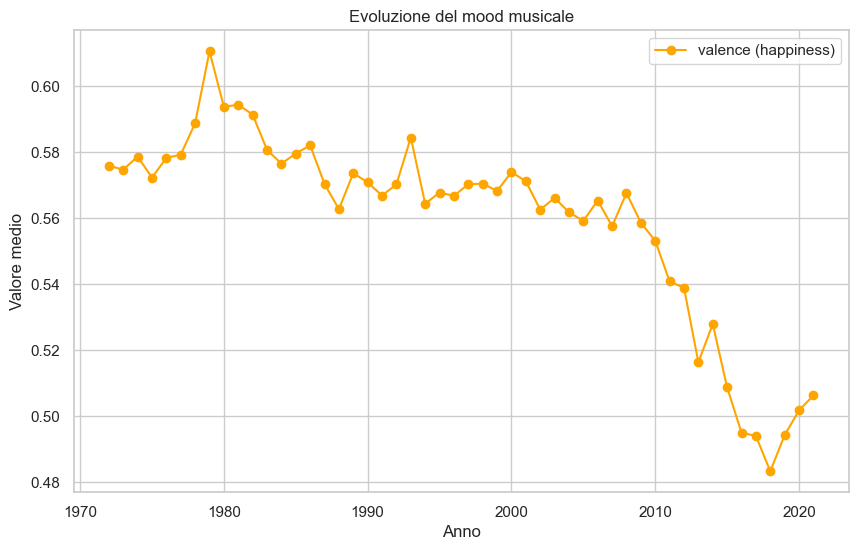

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(stats_by_year.index, stats_by_year['valence_mean'], marker = 'o', color = 'orange', label = 'valence (happiness)')
plt.title('Evoluzione del mood musicale')
plt.xlabel('Anno')
plt.ylabel('Valore medio')
plt.grid(True)
plt.legend()
plt.show()

Possiamo osservare che la valence dei brani era in lento calo a partire dal 1979, tuttavia si è velocizzato nel 2008, in concomitanza con la crisi economica e la transizione dalla musica indie rock/pop più  tradizionale verso musiche più indie pop elettroniche e sintetiche.  

Questa ipotesi è rafforzata analizzando l'andamento del 'energy' di un brano, ovvero la misura percettiva dell'intensità, della velocità e dell'attività di una canzone.

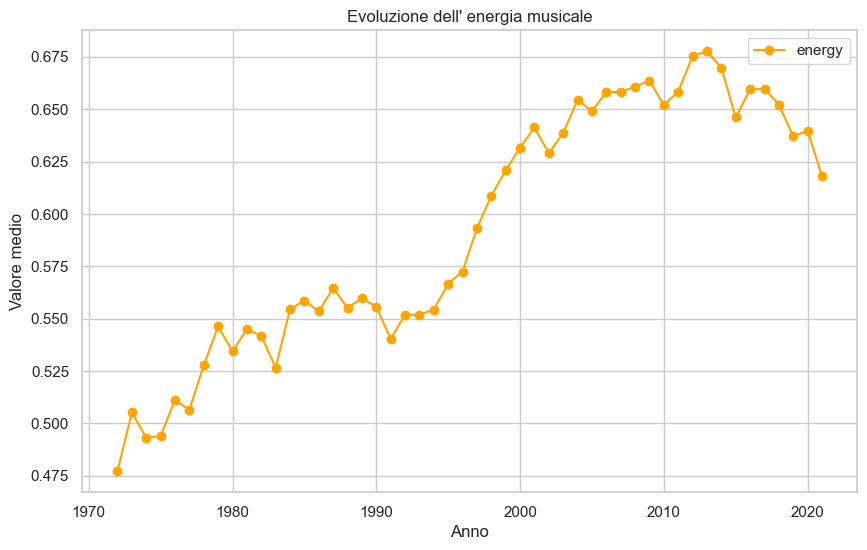

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(stats_by_year.index, stats_by_year['energy_mean'], marker = 'o', color = 'orange', label = 'energy')
plt.title("Evoluzione dell' energia musicale")
plt.xlabel('Anno')
plt.ylabel('Valore medio')
plt.grid(True)
plt.legend()
plt.show()

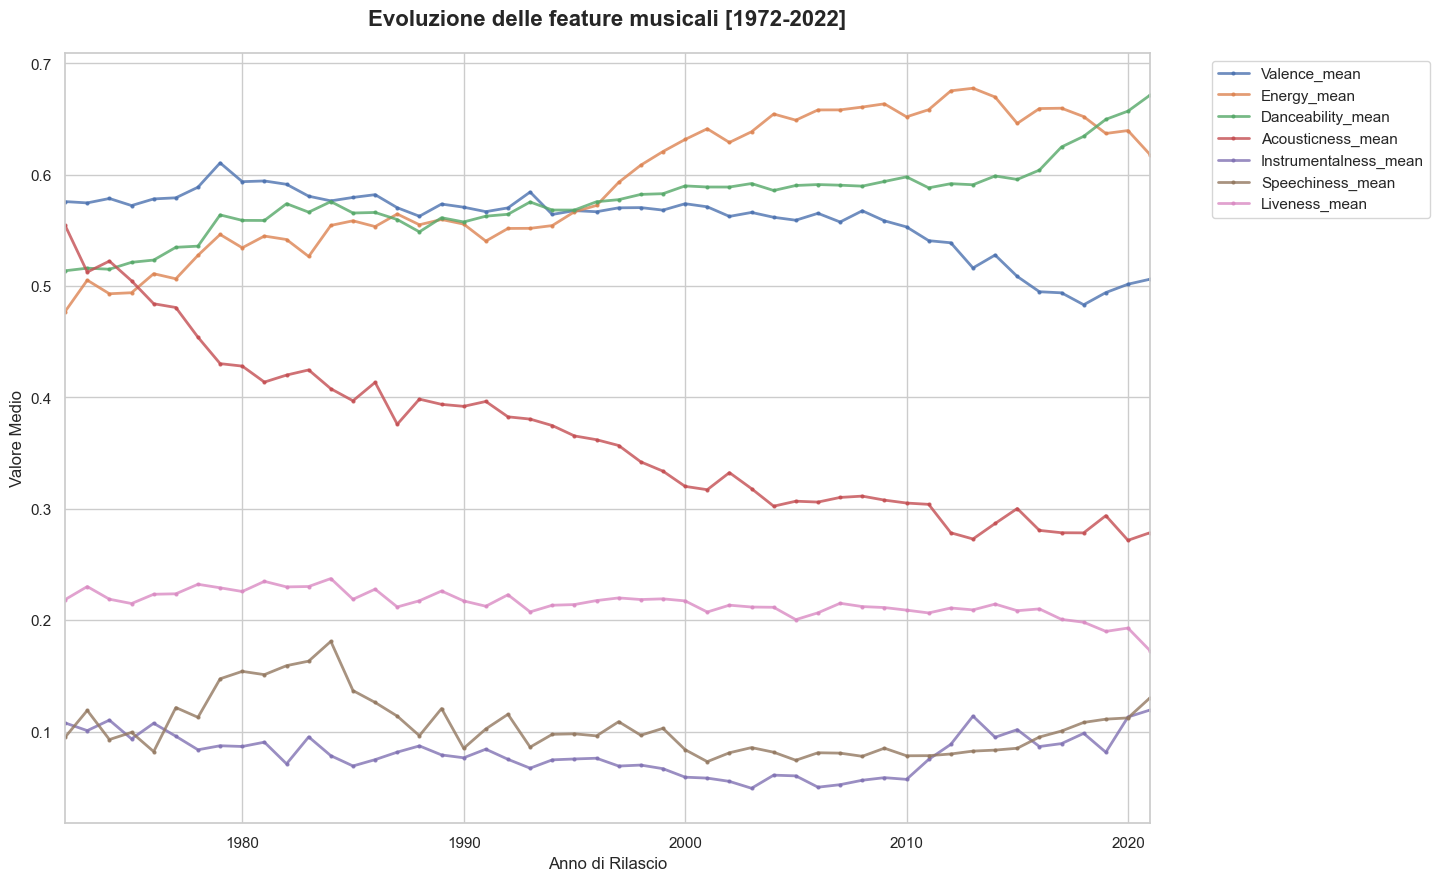

In [ ]:
def plot_full_trends(stats_by_year):
    features = ['valence_mean', 'energy_mean', 'danceability_mean', 'acousticness_mean', 'instrumentalness_mean', 'speechiness_mean', 'liveness_mean']
    
    plt.figure(figsize=(14, 10))
    
    # Usiamo un ciclo per plottare ogni feature

    for feature in features:
        data = stats_by_year[feature]
        
        plt.plot(
            stats_by_year.index, 
            data, 
            label=feature.capitalize(), 
            linewidth=2,
            marker='.', 
            markersize=4,
            alpha=0.8 
        )

    plt.title('Evoluzione delle feature musicali [1972-2022]', fontsize=16, fontweight='bold', pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Anno di Rilascio', fontsize=12)
    plt.ylabel('Valore Medio', fontsize=12)
    
    # Range degli anni (opzionale, utile se il dataset è molto vasto)
    plt.xlim(stats_by_year.index.min(), stats_by_year.index.max())

plot_full_trends(stats_by_year)

Questo grafico è estremamente informativo, ci permette di osservare come negli ultimi 50 anni, sebbene la 'felicità' dei brani sia diminuita, la loro ballabilità è invece aumentata.  

Osserviamo inoltre che l'acousticness dei brani, ovvero se un brano è stato registrato con strumenti acustici piuttosto che elettronici o amplificati artificialmente, ha continuato a diminuire, con l'avvento della musica elettronica.  

La liveness, ovvero la percezione che un brano sia 'dal vivo' è rimasta pressocché invariata, così come l'instrumentalness e la speechiness, ovvero se un brano ha un testo o se è solo musica.

In [ ]:
def show_tracks_correlation(tracks, start, end):
    tracks = tracks[(tracks['year'] >= start) & (tracks['year'] <= end)]

    features = ['valence', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'loudness', 'liveness', 'tempo']
    correlations = {}

    for f in features:
        correlations[f] = tracks['danceability'].corr(tracks[f])

    df_corr = pd.DataFrame({
        'Feature': list(correlations.keys()),
        'Value': list(correlations.values())
    }).sort_values(by='Value', ascending=True)

    plt.figure(figsize=(10, 8))
    colors = ['red' if x < 0 else 'green' for x in df_corr['Value']]

    plt.barh(df_corr['Feature'], df_corr['Value'], color=colors)

    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Correlazione tra Danceability e altre Audio Features [{start}-{end}]', fontsize=14)
    plt.xlabel('Coefficiente di Correlazione (r)', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    
    for i, v in enumerate(df_corr['Value']):
        plt.text(v, i, f' {v:.2f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()


Essendo la ballabilità dei brani ai suoi massimi storici ci si può chiedere a cosa sia legata, possiamo quindi verificare se vi è una correlazione tra le feature e la ballabilità

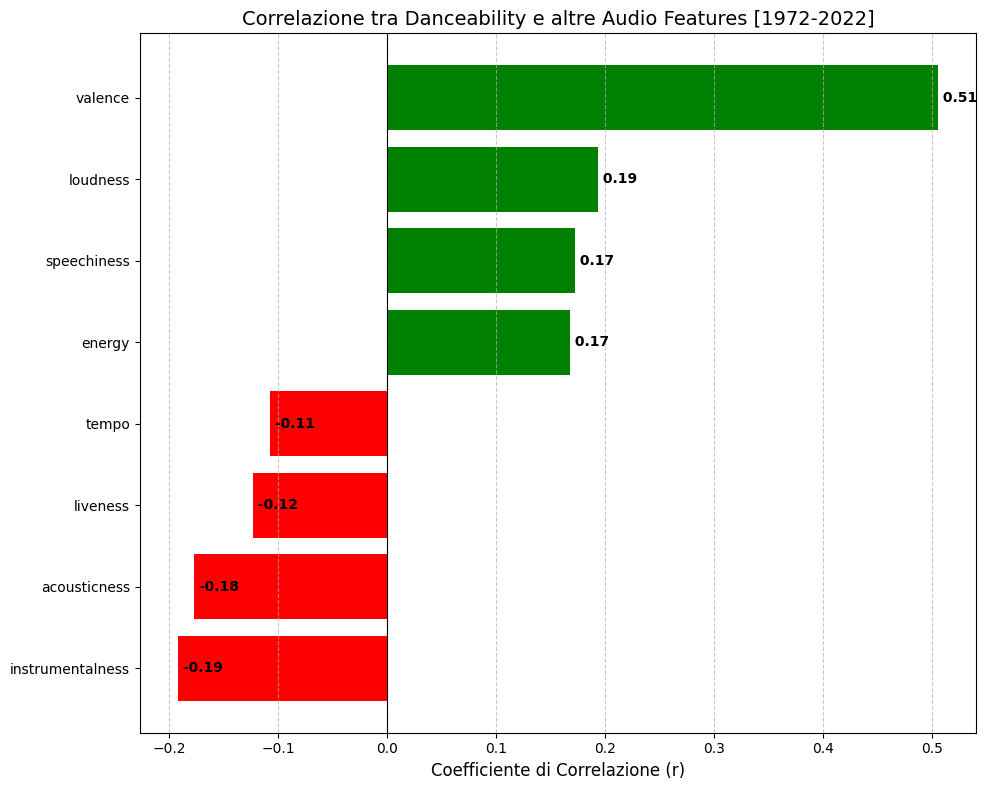

In [ ]:
show_tracks_correlation(tracks_df, 1972, 2022)

Osservando i dati degli ultimi 50 anni è possibile notare una buona correlazione positiva tra ballabilità e felicità di un brano.  

Valori come loudness, speechiness e energy hanno invece una debole correlazione positiva.

Valori come tempo, liveness, acousticness e instrumentallness, hanno invece una debole correlazione negativa.

È possibile dunque trarre la conclusione che più un brano è felice più è probabile che sia ballabile, non vi è una correlazione invece con il tempo o l'energia di un brano.
Questo grafico mostra però una media di tutti gli ultimi 50 anni, tali correlazioni variano anche a seconda del decennio?

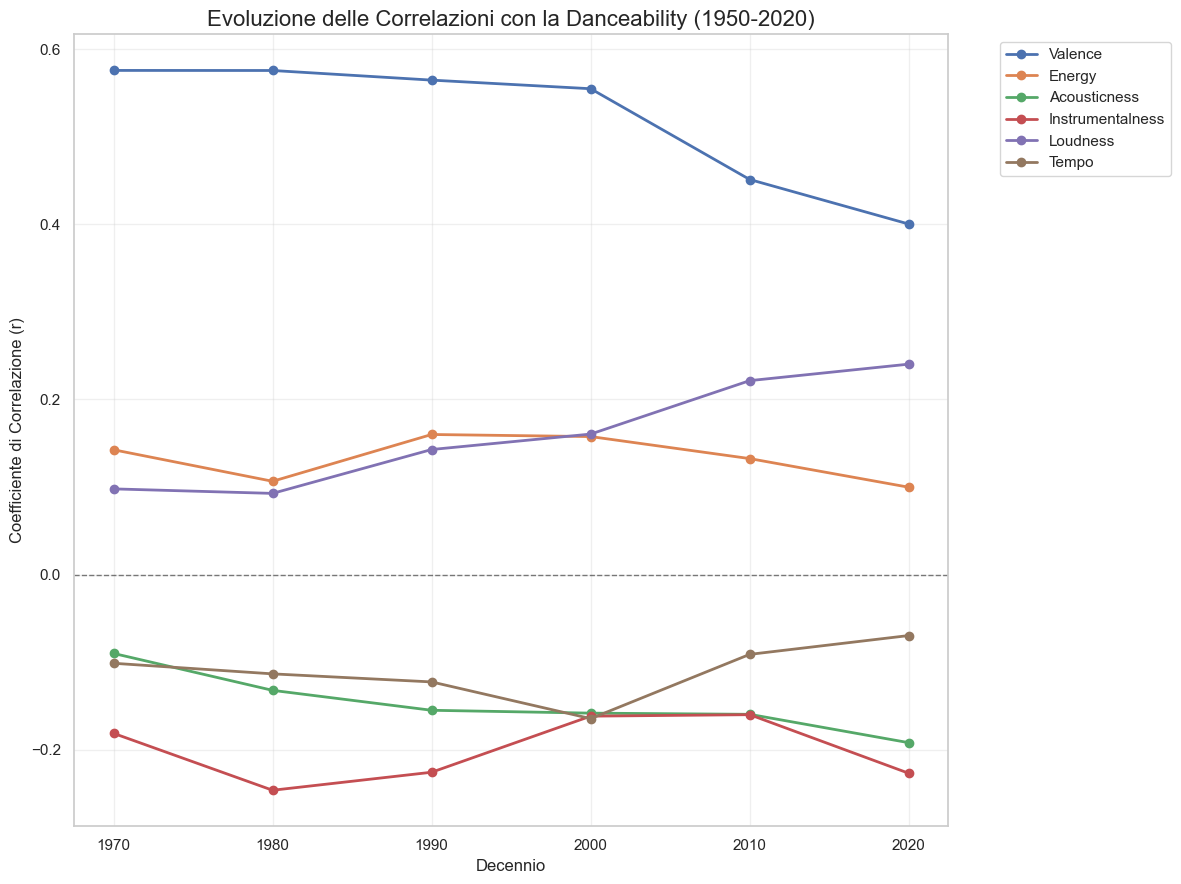

In [ ]:
def plot_correlation_trends(tracks_df):
    tracks_df['decade'] = (tracks_df['year'] // 10) * 10
    
    
    tracks_df = tracks_df[tracks_df['decade'] >= 1970]
    
    features = ['valence', 'energy', 'acousticness', 'instrumentalness', 'loudness', 'tempo']
    decades = sorted(tracks_df['decade'].unique())
    
    trend_data = []
    
    for decade in decades:
        decade_tracks = tracks_df[tracks_df['decade'] == decade]
        row = {'decade': decade}
        for f in features:
            row[f] = decade_tracks['danceability'].corr(decade_tracks[f])
        trend_data.append(row)
    
    df_trends = pd.DataFrame(trend_data).set_index('decade')
    
    plt.figure(figsize=(12, 9))
    
    for f in features:
        plt.plot(df_trends.index, df_trends[f], marker='o', linewidth=2, label=f.capitalize())
    
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5) # Linea dello zero
    plt.title('Evoluzione delle Correlazioni con la Danceability (1950-2020)', fontsize=16)
    plt.xlabel('Decennio', fontsize=12)
    plt.ylabel('Coefficiente di Correlazione (r)', fontsize=12)
    plt.xticks(decades)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fuori dal grafico
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


plot_correlation_trends(tracks_df)

## Conclusioni Finali

L'analisi statistica condotta sulle Audio Features ha permesso di evidenziare pattern storici significativi che riflettono la profonda evoluzione del mercato musicale e dei gusti sociali negli ultimi cinquant'anni.

In primo luogo, l'osservazione dei trend storici (1970-2022) rivela un'interessante dicotomia tra l'umore e il ritmo: mentre la **felicità** (*valence*) dei brani mainstream ha subito un declino costante (con un'accelerazione evidente dopo il 2008), la **ballabilità** (*danceability*) ha continuato a crescere fino a raggiungere i suoi massimi storici. Questo fenomeno evidenzia come l'era dei Social Media tenda a premiare una musica ritmicamente molto coinvolgente, ma accompagnata da un "mood" emotivamente più cupo e malinconico.

In secondo luogo, la matrice delle correlazioni ha dimostrato che la ballabilità non dipende affatto dalla velocità: il parametro *tempo* (BPM) mostra infatti una correlazione vicina allo zero. Al contrario, il drastico e continuo calo dell'*acousticness* conferma che la danceability moderna è ormai quasi esclusivamente legata a produzioni digitali ed elettroniche, allontanandosi drasticamente dalla strumentazione acustica o "live" del passato.

In sintesi, i dati quantitativi raccolti confermano che la musica è un potente indicatore sociale: gli algoritmi e i metadati dimostrano come le abitudini di ascolto si siano standardizzate attorno a ritmi forti e produzioni sintetiche, riadattando l'arte musicale ai nuovi modelli di consumo digitale.